In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
def load_surface(filename):
    """
    Load the black hole surface data from a .3d file.
    Assumes ASCII format with x y z per line.
    """
    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1], data[:, 2]

surface_file = "/anvil/scratch/x-colson1/abid_bot_yuheng/xml/3d_data_25_09_24_120048/bh1_000000.3d"
x, y, z = load_surface(surface_file)
print(f"Loaded {len(x)} points from {surface_file}")

Loaded 2166 points from /anvil/scratch/x-colson1/abid_bot_yuheng/xml/3d_data_25_09_24_120048/bh1_000000.3d


In [4]:
center = np.array([0.0, 0.0, 0.0])
spin_vec = np.array([-1.4588868030E-019,  -1.0619830425E-018,   1.9897670564E-003])

# Normalize the spin vector
spin_vec = spin_vec / np.linalg.norm(spin_vec)
print("Normalized spin vector:", spin_vec)

Normalized spin vector: [-7.33194772e-17 -5.33722296e-16  1.00000000e+00]


In [5]:
points = np.vstack((x, y, z)).T
vecs = points - center

# Project each vector onto the spin direction
projections = vecs @ spin_vec

# Find the point with the max projection along the spin direction
idx = np.argmax(projections)
surface_point = points[idx]

print("Best surface point to place spin vector at:")
print("Coordinates:", surface_point)

Best surface point to place spin vector at:
Coordinates: [-3.31781605e-18 -3.31781605e-18  7.96912807e-02]


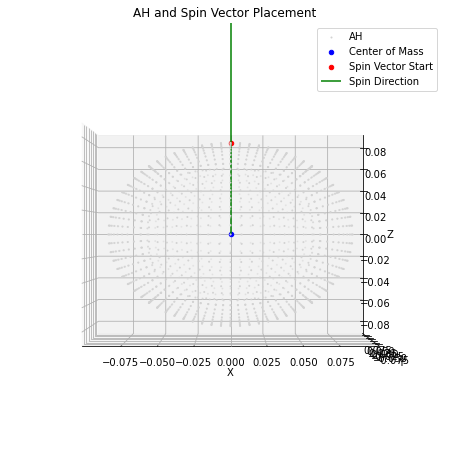

In [6]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, color='lightgray', s=1, label='AH')

ax.scatter(*center, color='blue', label='Center of Mass')
ax.scatter(*surface_point, color='red', label='Spin Vector Start')
ax.quiver(*center, *spin_vec, length=1.0, color='green', label='Spin Direction')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
ax.set_title('AH and Spin Vector Placement')
ax.view_init(elev=0, azim=270)
plt.show()